In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"E:\SMS Spam Classification\spam.csv", encoding='latin1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
385,ham,It took Mr owl 3 licks,NaN,NaN,NaN
485,ham,If we win its really no 1 side for long time.,NaN,NaN,NaN
1272,ham,Ok...,NaN,NaN,NaN
5208,ham,Hi.what you think about match?,NaN,NaN,NaN
2040,ham,You always make things bigger than they are,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

#### **1 Data Cleaning**
#### **2 EDA**
#### **3 Text Preprocessing**
#### **4 Model Building**
#### **5 Evaluation**
#### **6 Imporvements**
#### **7 Website**
#### **8 Deploy**

## **Data Cleaning**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.drop(columns = ["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace = True)

In [7]:
df.sample(5)

,v1,v2
3157,ham,Thank u. IT BETTER WORK OUT CAUSE I WILL FEEL ...
3919,spam,FREE>Ringtone! Reply REAL or POLY eg REAL1 1. ...
2198,ham,I'm in a movie. Call me 4 wat?
1073,ham,Lul im gettin some juicy gossip at the hospita...
4154,spam,Want a new Video Phone? 750 anytime any networ...


In [8]:
df.rename(columns = {"v1":"Target","v2":"Text"},inplace = True)

In [9]:
df.sample(5)

,Target,Text
388,spam,4mths half price Orange line rental & latest c...
3335,ham,Then u go back urself lor...
2874,ham,"Idk. You keep saying that you're not, but sinc..."
5230,ham,"Nope, I'm still in the market"
1629,ham,Sounds like you have many talents! would you l...


In [10]:
label = LabelEncoder()
df["Target"] = label.fit_transform(df["Target"])
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df = df.drop_duplicates(keep = "first")

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

## **EDA**

In [16]:
df["Target"].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

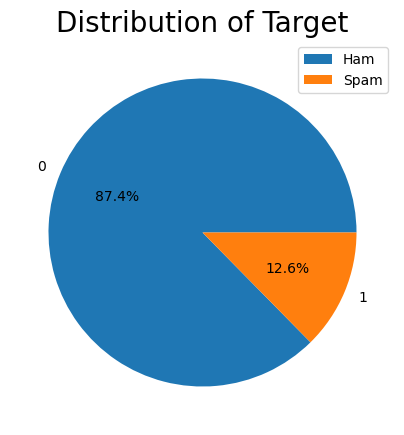

In [17]:
plt.figure(figsize = (5,5))
plt.pie(df["Target"].value_counts(),labels = df["Target"].value_counts().index,autopct = "%1.1f%%")
plt.title("Distribution of Target",fontsize = 20)
plt.legend(["Ham","Spam"])
plt.show()

# **It is clear that data is imbalanced**

In [18]:
import nltk

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\UMC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
from nltk import word_tokenize

In [21]:
from nltk import sent_tokenize

In [22]:
import warnings
warnings.filterwarnings("ignore")
import nltk   

In [23]:
df["num_characters"] = df["Text"].apply(len)

In [24]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
df["num_words"] = df["Text"].apply(lambda x: len(word_tokenize(x)))

In [26]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [27]:
df["num_sentences"] = df["Text"].apply(lambda x : len(nltk.sent_tokenize(x)))

In [28]:
df.head()

,Target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [29]:
df.describe()

,Target,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [30]:
df[df["Target"] == 0][["num_characters",	"num_words",	"num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
ham_df = df[df["Target"] == 0][["num_characters",	"num_words",	"num_sentences"]]

In [32]:
df[df["Target"] == 1][["num_characters",	"num_words",	"num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [33]:
spam_df = df[df["Target"] == 1][["num_characters",	"num_words",	"num_sentences"]]

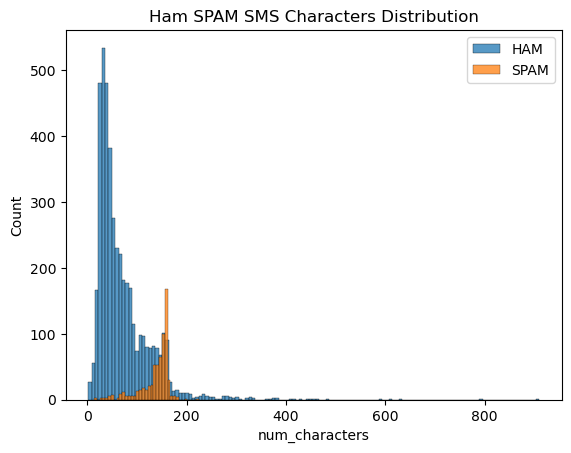

In [34]:
sns.histplot(ham_df["num_characters"],label = "HAM")
sns.histplot(spam_df["num_characters"],label = "SPAM")
plt.title("Ham SPAM SMS Characters Distribution")
plt.legend()
plt.show()

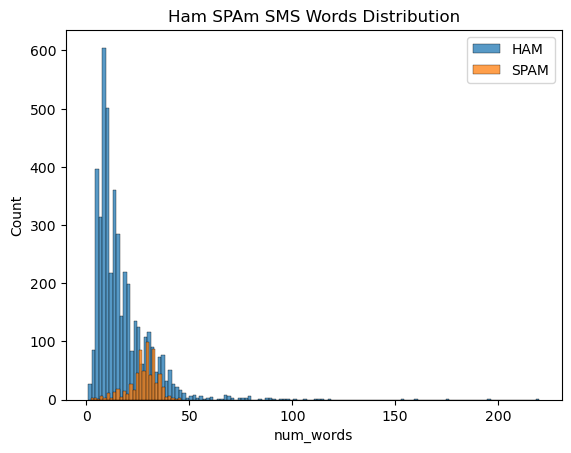

In [35]:
sns.histplot(ham_df["num_words"],label = "HAM")
sns.histplot(spam_df["num_words"],label = "SPAM")
plt.title("Ham SPAm SMS Words Distribution")
plt.legend()
plt.show()

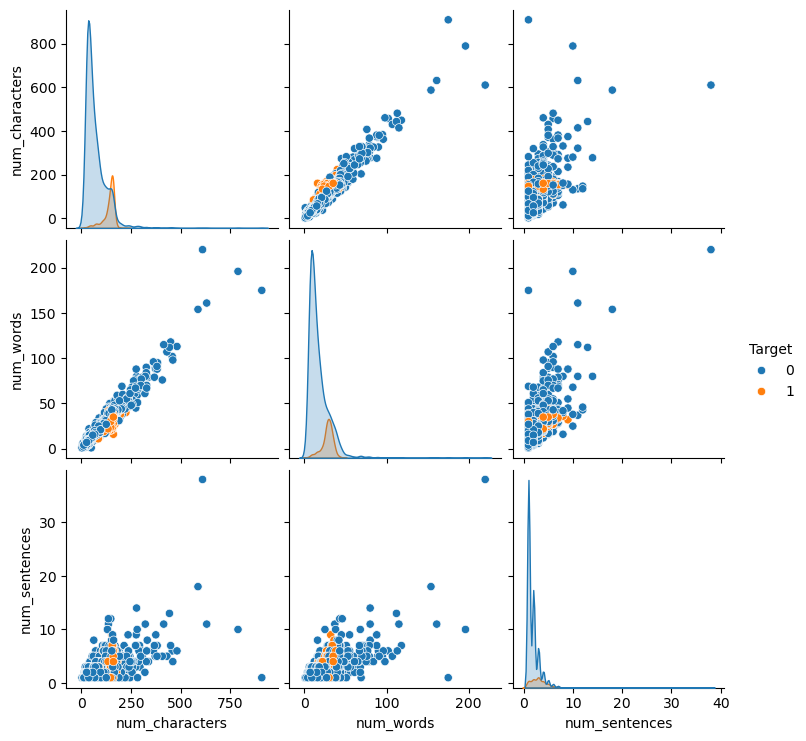

In [36]:
sns.pairplot(df,hue = "Target")
plt.show()
plt.close()

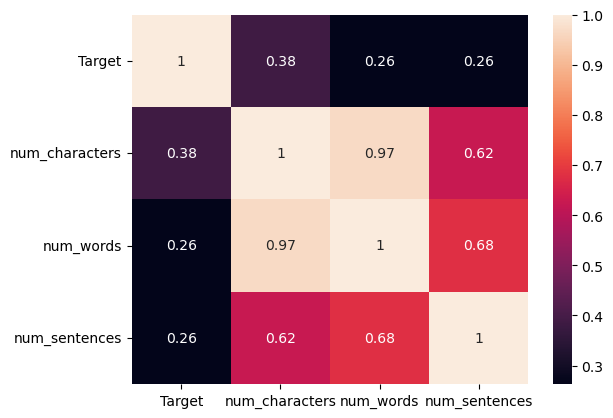

In [37]:
sns.heatmap(df[["Target","num_characters",	"num_words",	"num_sentences"]].corr(),annot = True)
plt.show()
plt.close()

In [38]:
df.head()

,Target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


# **Text Preprocessing**

In [39]:
from nltk.corpus import stopwords
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [40]:
import string 
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [41]:
punctuation = list(string.punctuation)
print(len(punctuation))
print(punctuation)

32
['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']


In [42]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [43]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [44]:
transform_text("Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...")

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [45]:
df["Text"][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [46]:
df["transformed_text"] = df["Text"].apply(transform_text)

In [47]:
df.head(5)

,Target,Text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [48]:
from wordcloud import WordCloud

In [49]:
wc = WordCloud(width = 500,height = 500,background_color = "white")

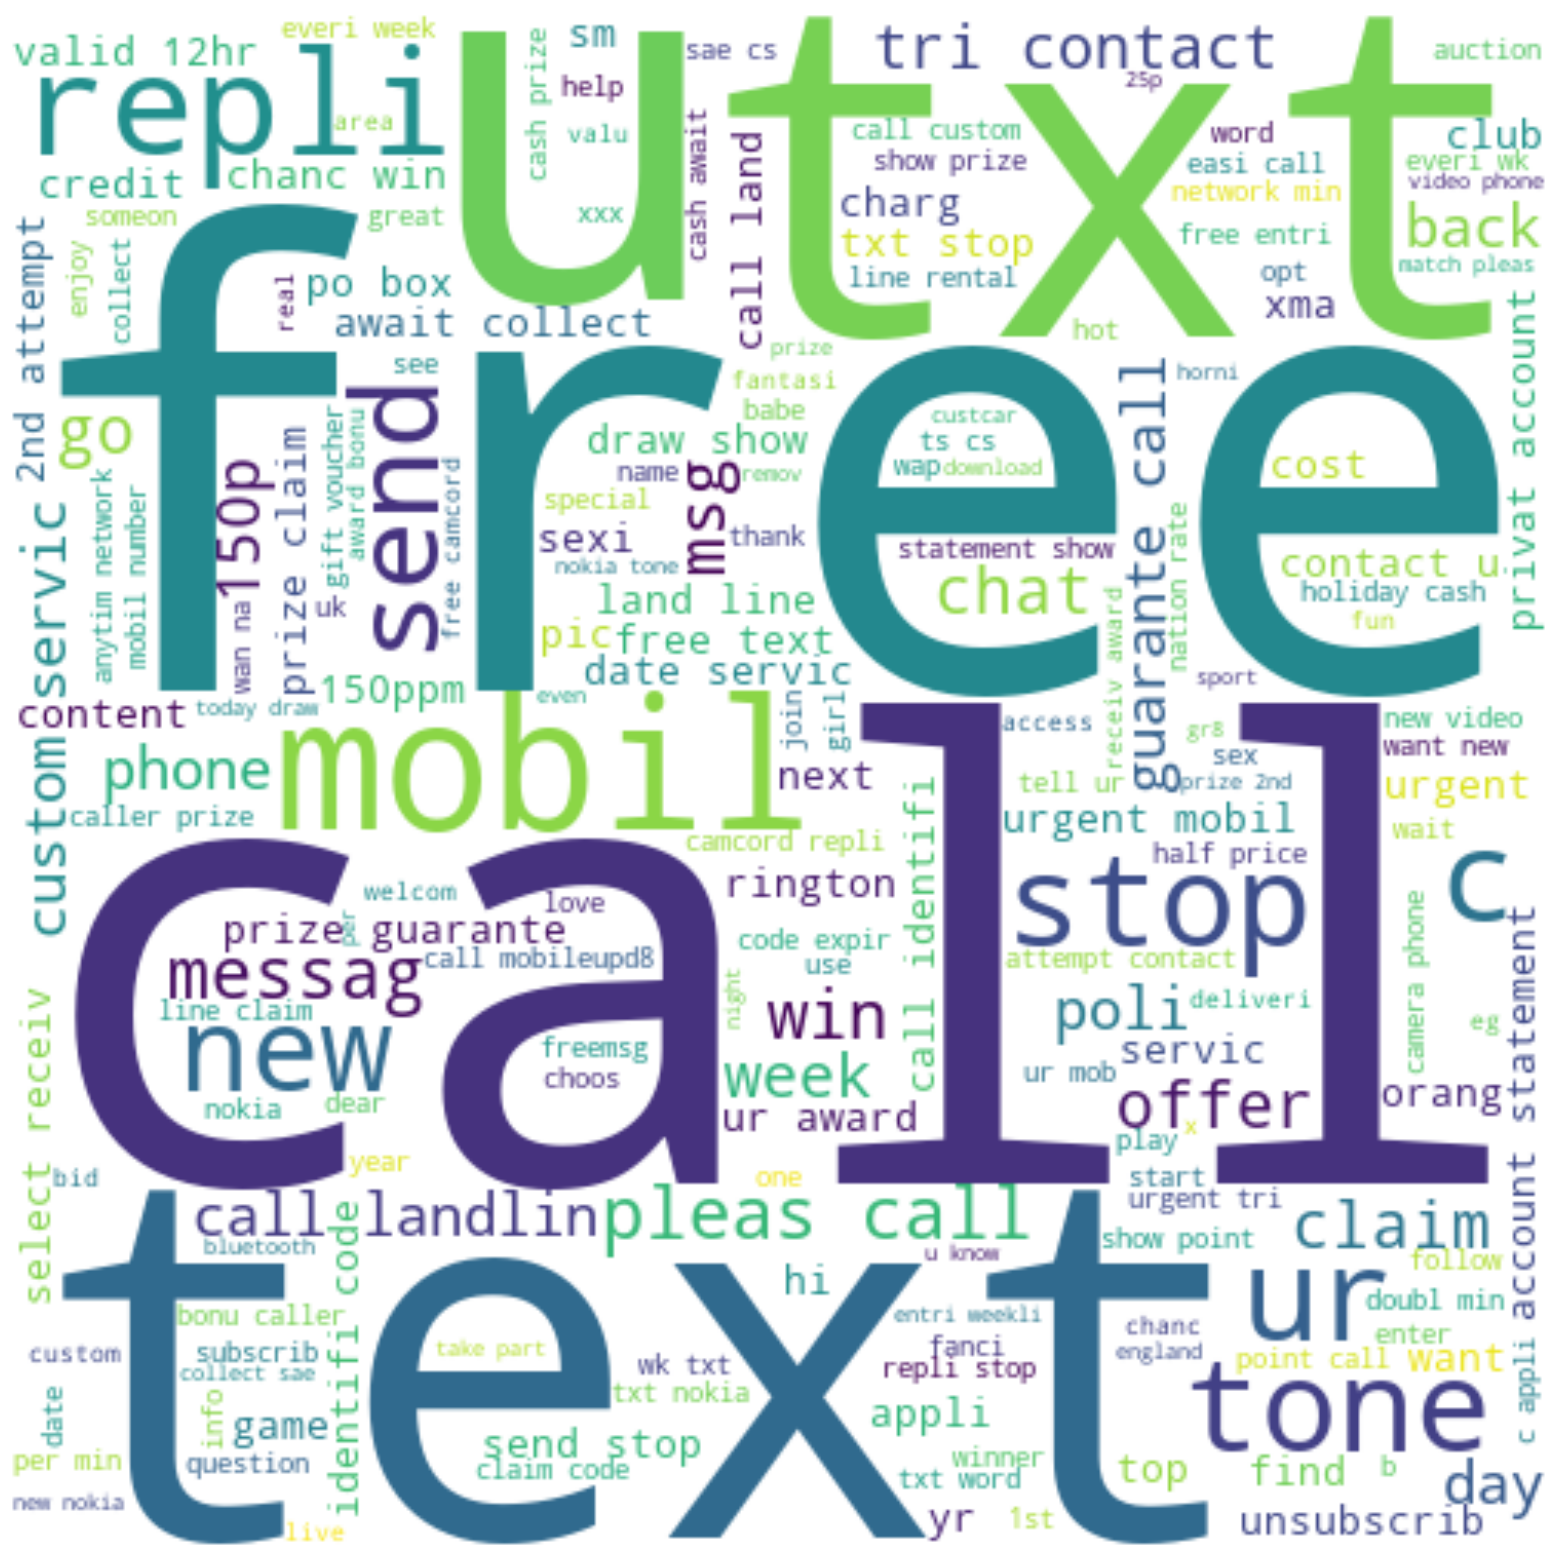

In [50]:
plt.figure(figsize = (20,20))
spam_word_cloud = wc.generate(df[df["Target"] == 1]["transformed_text"].str.cat(sep = " "))
plt.imshow(spam_word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

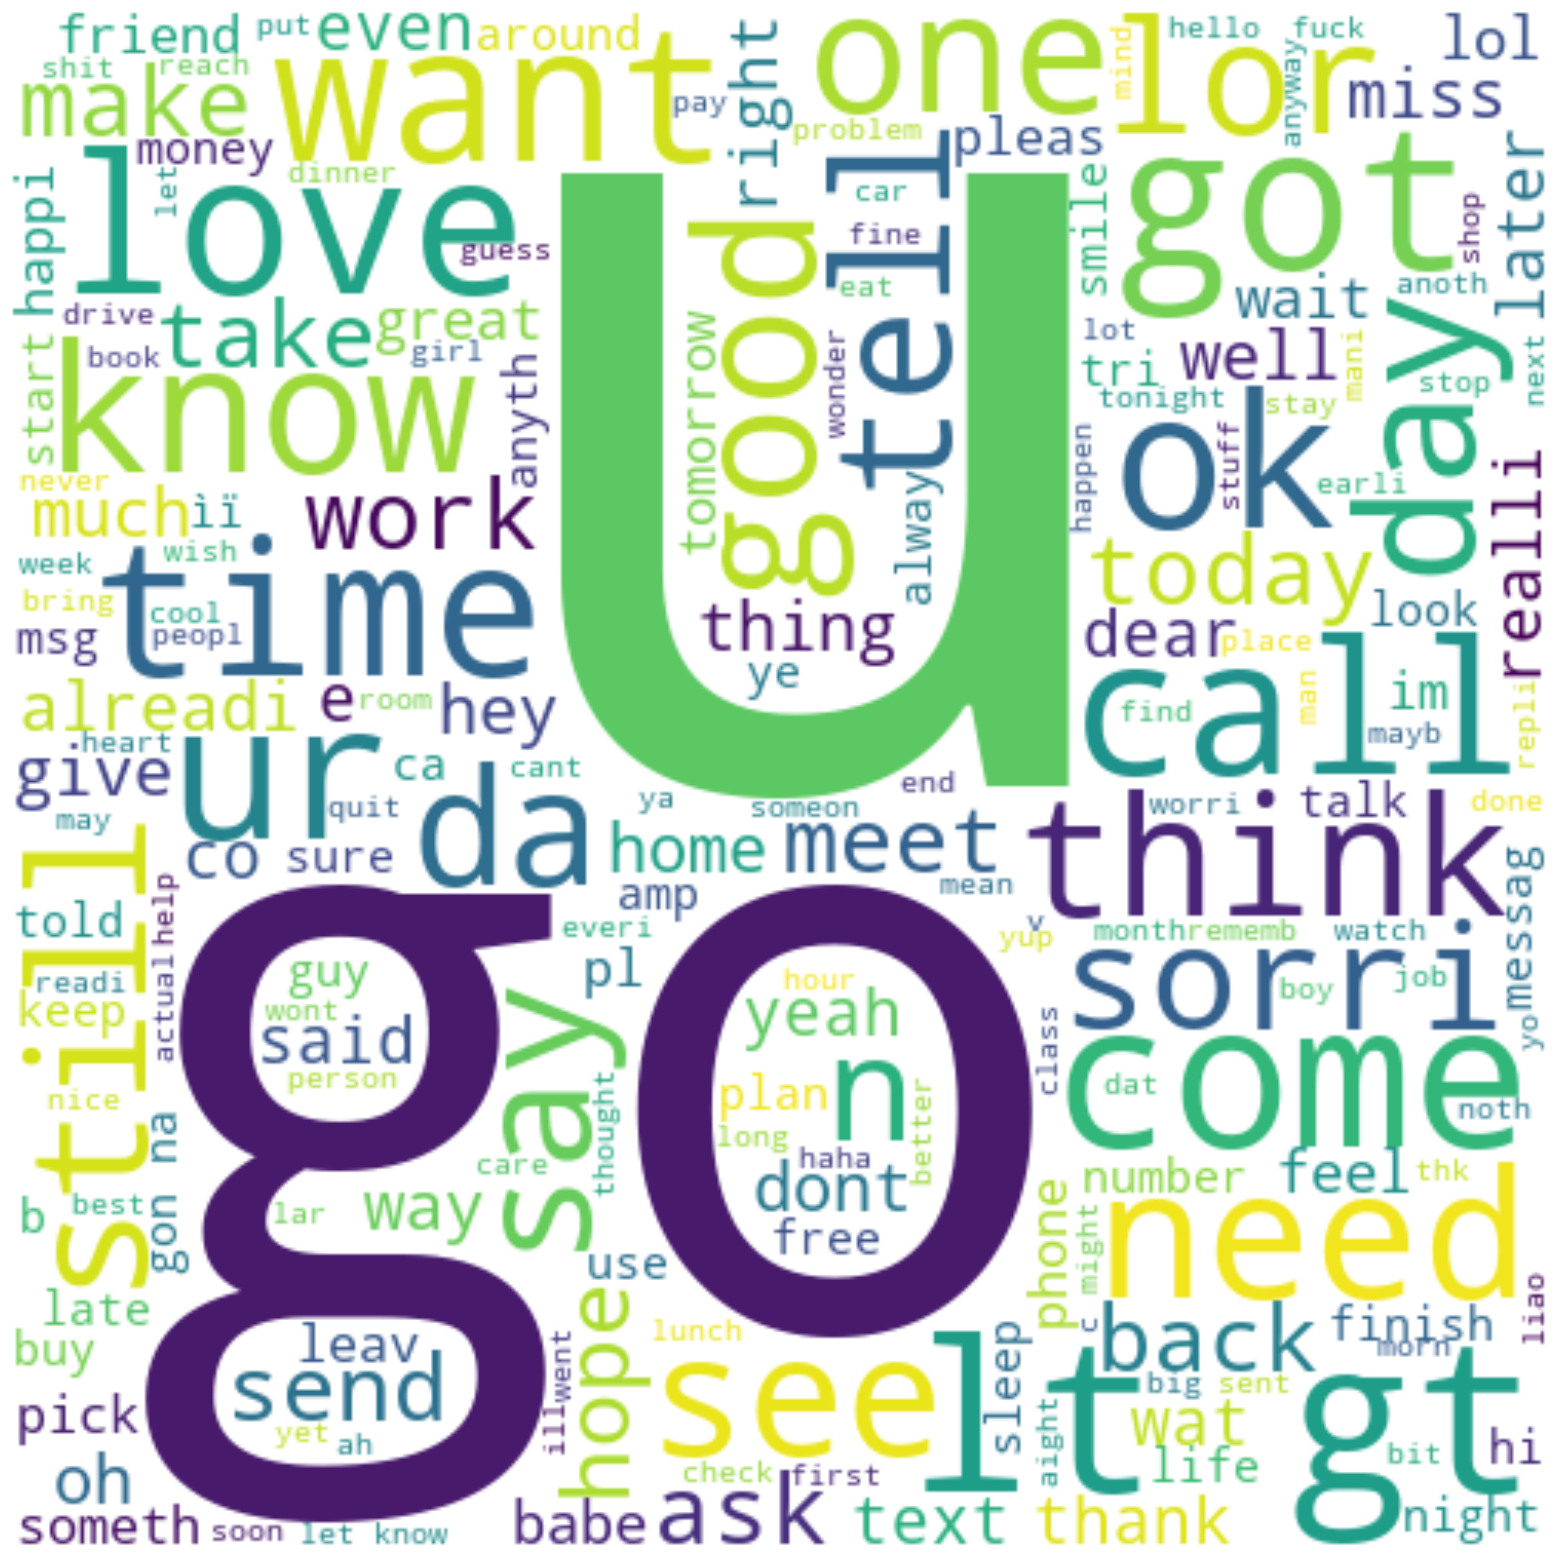

In [51]:
wc = WordCloud(width = 500,height = 500,background_color = "white")
plt.figure(figsize = (20,20))
ham_word_cloud = wc.generate(df[df["Target"] == 0]["transformed_text"].str.cat(sep = " "))
plt.imshow(ham_word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [52]:
msg_ham = []
for i in df[df["Target"] == 0]["transformed_text"]:
     for j in i.split():
         msg_ham.append(j)

In [53]:
dict = {}
for i in msg_ham:
    dict[i] = msg_ham.count(i)

In [54]:
msg_spam = []
for i in df[df["Target"] == 1]["transformed_text"]:
     for j in i.split():
         msg_spam.append(j)

In [55]:
dict1 = {}
for i in msg_spam:
    dict1[i] = msg_spam.count(i)

In [56]:
top_30 = sorted(dict.items(), key=lambda x: x[1], reverse=True)[:30]
print(top_30)

[('u', 883), ('go', 404), ('get', 349), ('gt', 288), ('lt', 287), ('2', 284), ('come', 275), ('got', 236), ('know', 236), ('like', 234), ('call', 233), ('time', 219), ('ok', 217), ('love', 216), ('good', 213), ('want', 208), ('ur', 197), ('day', 190), ('need', 170), ('one', 165), ('lor', 159), ('4', 156), ('home', 152), ('think', 149), ('see', 147), ('take', 143), ('still', 143), ('da', 142), ('tell', 133), ('make', 129)]


In [57]:
top_301 = sorted(dict1.items(), key=lambda x: x[1], reverse=True)[:30]
print(top_301)

[('call', 320), ('free', 191), ('2', 155), ('txt', 141), ('text', 122), ('u', 119), ('ur', 119), ('mobil', 114), ('stop', 104), ('repli', 103), ('claim', 98), ('4', 97), ('prize', 82), ('get', 74), ('new', 64), ('servic', 64), ('tone', 63), ('send', 60), ('urgent', 57), ('nokia', 57), ('contact', 56), ('award', 55), ('phone', 52), ('cash', 51), ('pleas', 51), ('week', 49), ('win', 48), ('c', 45), ('collect', 45), ('min', 45)]


In [58]:
ham = pd.DataFrame(top_30)
spam = pd.DataFrame(top_301)

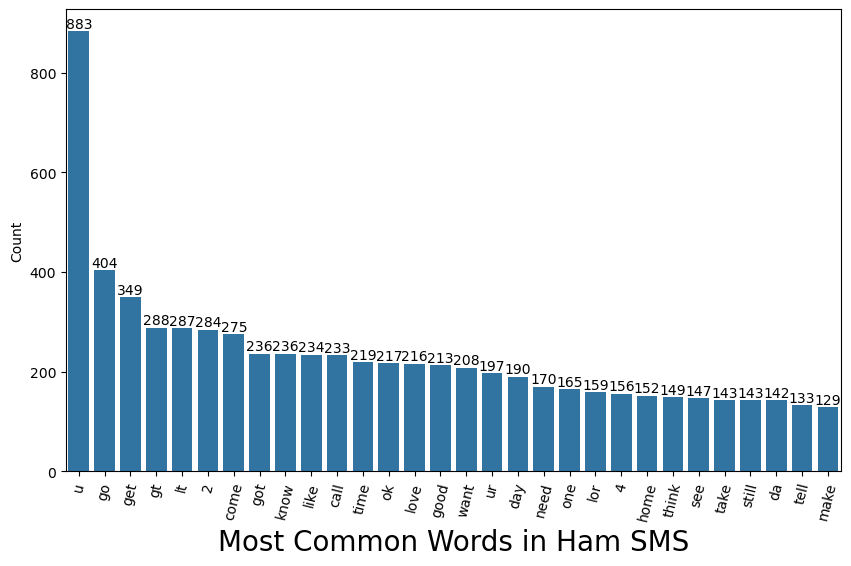

In [59]:
plt.figure(figsize = (10,6))
ax = sns.barplot(x = ham[0],y = ham[1])
for i in ax.containers:
    ax.bar_label(i)
plt.ylabel("Count")
plt.xlabel("Most Common Words in Ham SMS",fontsize = 20)
plt.xticks(rotation = 76)
plt.show()

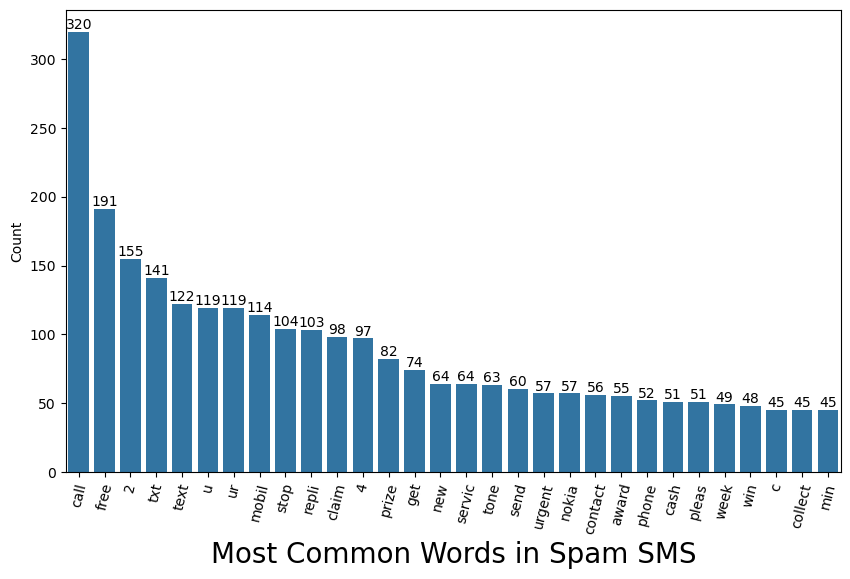

In [60]:
plt.figure(figsize = (10,6))
ax = sns.barplot(x = spam[0],y = spam[1])
for i in ax.containers:
    ax.bar_label(i)
plt.ylabel("Count")
plt.xlabel("Most Common Words in Spam SMS",fontsize = 20)
plt.xticks(rotation = 76)
plt.show()

# **Model Building** 

In [61]:
v = TfidfVectorizer()
X = v.fit_transform(df["transformed_text"]).toarray()

In [62]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [63]:
X.shape

(5169, 6708)

In [64]:
y = df["Target"].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [65]:
x_train ,x_test ,y_train ,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [66]:
print(pd.Series(y_train).value_counts(normalize = True))
print(pd.Series(y_test).value_counts(normalize = True))

0    0.873761
1    0.126239
Name: proportion, dtype: float64
0    0.873308
1    0.126692
Name: proportion, dtype: float64


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score

In [68]:
lr = LogisticRegression(max_iter = 1000,penalty = "l2")
knn = KNeighborsClassifier(n_neighbors = 3)
dt = DecisionTreeClassifier()
sv = SVC()

In [69]:
lr.fit(x_train,y_train)
yhat1 = lr.predict(x_test)
print("accuracy : ",accuracy_score(y_test,yhat1))
print(classification_report(y_test,yhat1))
print("precision : ",precision_score(y_test,yhat1))

accuracy :  0.9516441005802708
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       903
           1       1.00      0.62      0.76       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.95      1034

precision :  1.0


In [70]:
knn.fit(x_train,y_train)
yhat1 = knn.predict(x_test)
print("accuracy : ",accuracy_score(y_test,yhat1))
print(classification_report(y_test,yhat1))
print("precision : ",precision_score(y_test,yhat1))

accuracy :  0.913926499032882
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       903
           1       1.00      0.32      0.49       131

    accuracy                           0.91      1034
   macro avg       0.96      0.66      0.72      1034
weighted avg       0.92      0.91      0.89      1034

precision :  1.0


In [71]:
dt.fit(x_train,y_train)
yhat1 = dt.predict(x_test)
print("accuracy : ",accuracy_score(y_test,yhat1))
print(classification_report(y_test,yhat1))
print("precision : ",precision_score(y_test,yhat1))

accuracy :  0.9487427466150871
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       903
           1       0.79      0.81      0.80       131

    accuracy                           0.95      1034
   macro avg       0.88      0.89      0.89      1034
weighted avg       0.95      0.95      0.95      1034

precision :  0.7910447761194029


In [72]:
sv.fit(x_train,y_train)
yhat1 = sv.predict(x_test)
print("accuracy : ",accuracy_score(y_test,yhat1))
print(classification_report(y_test,yhat1))
print("precision : ",precision_score(y_test,yhat1))

accuracy :  0.9700193423597679
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       1.00      0.76      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

precision :  1.0


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [74]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [75]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt
}

In [78]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [79]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9777562862669246
Precision -  0.9821428571428571
For  KN
Accuracy -  0.9013539651837524
Precision -  1.0
For  NB
Accuracy -  0.965183752417795
Precision -  1.0
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8018867924528302
For  LR
Accuracy -  0.9584139264990329
Precision -  0.9489795918367347
For  RF
Accuracy -  0.9729206963249516
Precision -  1.0
For  AdaBoost
Accuracy -  0.9235976789168279
Precision -  0.7708333333333334
For  BgC
Accuracy -  0.9487427466150871
Precision -  0.819672131147541
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9646017699115044
For  GBDT
Accuracy -  0.9497098646034816
Precision -  0.9072164948453608


In [82]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Accuracy',ascending=False)

In [83]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.977756,0.982143
8,ETC,0.974855,0.964602
5,RF,0.972921,1.000000
2,NB,0.965184,1.000000
4,LR,0.958414,0.948980
9,GBDT,0.949710,0.907216
7,BgC,0.948743,0.819672
3,DT,0.935203,0.801887
6,AdaBoost,0.923598,0.770833
1,KN,0.901354,1.000000


In [84]:
import pickle

In [88]:
pickle.dump(v,open("vectorizer.pkl","wb"))
pickle.dump(rfc,open("model.pkl","wb"))